**Autor:** Andrés Alejandro Rodríguez Lozano  
**Portafolio:** Portafolio de Andrés Alejandro Rodríguez Lozano

# Capítulo 9 — Frontera eficiente

Simulación Monte Carlo long-only con **peso máximo 50%** por activo.  
Útil para discutir sobreajuste *ex-post*; **no** es una señal de trading.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({
    'figure.dpi': 56,
    'savefig.dpi': 56,
    'figure.figsize': (8, 3.8),
    'font.size': 9,
    'svg.fonttype': 'none',
    'path.simplify': True,
    'path.simplify_threshold': 0.2,
})

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
import portfolio_utils as pu

def load_monthly():
    """Carga precios mensuales: cache mensual, diario, o yfinance."""
    mpath = ROOT / 'data' / 'precios_mensuales.csv'
    if mpath.exists():
        print('Precios mensuales (cache):', mpath.name)
        return pd.read_csv(mpath, index_col=0, parse_dates=True).loc[: '2026-09-30']
    csv = ROOT / 'data' / 'precios_ajustados_diarios.csv'
    if csv.exists():
        daily = pd.read_csv(csv, index_col=0, parse_dates=True)
        print('Precios diarios (cache):', csv.name)
        return pu.to_month_end(daily).loc[: '2026-09-30']
    tickers = sorted(set(list(pu.CURRENT_WEIGHTS) + [pu.BENCHMARK]))
    print('Descargando precios con yfinance…')
    daily = pu.download_prices(tickers)
    return pu.to_month_end(daily).loc[: '2026-09-30']


monthly = load_monthly()
cols = list(pu.CURRENT_WEIGHTS)
rets = monthly.pct_change().loc['2016-01-31':'2026-09-30', cols].dropna()
fr, special = pu.efficient_frontier(rets, n_portfolios=800, max_weight=0.5, seed=42)
print('Máx Sharpe (aprox.):', {t: round(float(w), 3) for t, w in zip(cols, special['max_sharpe'])})
print('  ret/vol/sharpe:', {k: round(float(special['max_sharpe_stats'][k]), 4) for k in ['ret', 'vol', 'sharpe']})
print('Mín vol (aprox.):', {t: round(float(w), 3) for t, w in zip(cols, special['min_vol'])})


Precios mensuales (cache): precios_mensuales.csv
Máx Sharpe (aprox.): {'SPYG': 0.035, 'SMH': 0.459, 'BRK-B': 0.445, 'IEMG': 0.047, 'VTI': 0.013}
  ret/vol/sharpe: {'ret': 0.2326, 'vol': 0.184, 'sharpe': 1.2642}
Mín vol (aprox.): {'SPYG': 0.269, 'SMH': 0.001, 'BRK-B': 0.392, 'IEMG': 0.279, 'VTI': 0.059}


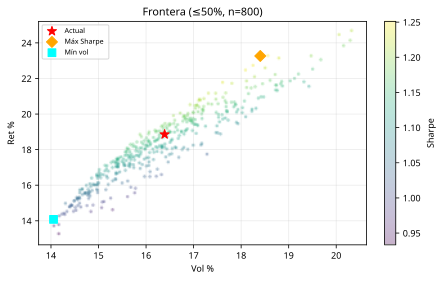

In [2]:
# Frontera simulada — scatter matplotlib (rasterizado, compacto)
mu = rets.mean().values * 12
cov = rets.cov().values * 12
w_cur = np.array([pu.CURRENT_WEIGHTS[t] for t in cols])
ret_c = float(w_cur @ mu)
vol_c = float(np.sqrt(w_cur @ cov @ w_cur))

# Submuestreo visual para SVG pequeño (los puntos especiales se dibujan aparte)
plot_fr = fr.iloc[::2]

fig, ax = plt.subplots(figsize=(6.2, 4.0))
sc = ax.scatter(
    plot_fr.vol * 100, plot_fr.ret * 100, c=plot_fr.sharpe, cmap='viridis',
    s=5, alpha=0.3, rasterized=True,
)
plt.colorbar(sc, ax=ax, label='Sharpe', fraction=0.046)
ax.scatter([vol_c * 100], [ret_c * 100], c='red', s=90, marker='*', label='Actual', zorder=5)
ax.scatter(
    [special['max_sharpe_stats']['vol'] * 100],
    [special['max_sharpe_stats']['ret'] * 100],
    c='orange', s=60, marker='D', label='Máx Sharpe', zorder=5,
)
ax.scatter(
    [special['min_vol_stats']['vol'] * 100],
    [special['min_vol_stats']['ret'] * 100],
    c='cyan', s=60, marker='s', label='Mín vol', zorder=5,
)
ax.set_xlabel('Vol %')
ax.set_ylabel('Ret %')
ax.set_title('Frontera (≤50%, n=800)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## Conclusiones
1. Óptimo *ex-post* no es estrategia futura.
2. Tope 50% evita degeneración en un solo activo.

## Ejercicios
1. Repite con `max_weight=1.0` y compara concentración.
2. Cambia `n_portfolios` a 5000: ¿cambia el máx Sharpe?
